In [1]:
"""
LSTM Flood Forecasting Model
Predicts streamflow 24 hours ahead using the top30 high flood-severity sites.
"""
import torch
import numpy as np
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping

from src.preprocessing.preprocessing import processor
from src.models.lstm import LSTMModel
from src.utils.helpers import create_sequences

WINDOW_SIZE = 72

In [2]:
pcr = processor.load(name="default_preprocessor")
pcr.pull_wandb()
print(pcr.df["site_id"].unique())
print(pcr.df.shape)
train_X, val_X, test_X, train_y, val_y, test_y = pcr.return_outputs()

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from C:\Users\sacha\_netrc.
wandb: Downloading large artifact 'flood-dataset-top30:latest', 145.19MB. 1 files...
wandb:   1 of 1 files downloaded.  
Done. 00:00:00.6 (232.3MB/s)


Starting preprocessing: 4,818,417 rows, 31 columns
After lag null removal: 3,412,815 rows, 28 features
Splitting by time...
Train: 2,730,278 | Val: 341,318 | Test: 341,219
Scaling features and targets...
Scaling complete.
shape: (37,)
Series: 'site_id' [str]
[
	"06799315"
	"06308500"
	"06921590"
	"06446700"
	"06793000"
	…
	"06803513"
	"06464100"
	"06803495"
	"06447500"
	"06784000"
]
(4818417, 31)


In [3]:
print("Creating sequences...")
X_train, y_train, train_site_ids = create_sequences(train_X, train_y, WINDOW_SIZE)
X_val, y_val, val_site_ids = create_sequences(val_X, val_y, WINDOW_SIZE)
X_test, y_test, test_site_ids = create_sequences(test_X, test_y, WINDOW_SIZE)
print("Sequences created.")

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")


Creating sequences...
Sequences created.
Train: (2727758, 72, 28), Val: (338798, 72, 28), Test: (338699, 72, 28)


In [4]:
lstm = LSTMModel(
    lstm_units=(32, 16),
    dense_units=64,
    dropout_rate=0.3,
    under_predict_penalty=2.0,
    learning_rate=1e-3,
)

lstm.build(input_shape=(WINDOW_SIZE, X_train.shape[2]))
lstm.summary()

# %%
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
)

lstm.fit(
    (X_train, y_train),
    val_ds=(X_val, y_val),
    epochs=50,
    callbacks=[early_stopping],
    batch_size=32,
)

c:\Users\sacha\RiceLocal\Capstone\Coding\Flood-Forecasting\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 72, 32)         │         7,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 72, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 16)             │         3,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         1,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,097 (47.25 KB)

 Trainable params: 12,097 (47.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
85243/85243 ━━━━━━━━━━━━━━━━━━━━ 1024s 12ms/step - loss: 0.4729 - mae: 0.1810 - val_loss: 0.4725 - val_mae: 0.1644
Epoch 2/50
85243/85243 ━━━━━━━━━━━━━━━━━━━━ 1010s 12ms/step - loss: 0.4204 - mae: 0.1676 - val_loss: 0.5155 - val_mae: 0.1996
Epoch 3/50
85243/85243 ━━━━━━━━━━━━━━━━━━━━ 1001s 12ms/step - loss: 0.3911 - mae: 0.1636 - val_loss: 0.5341 - val_mae: 0.2147
Epoch 4/50
85243/85243 ━━━━━━━━━━━━━━━━━━━━ 1004s 12ms/step - loss: 0.4057 - mae: 0.1751 - val_loss: 0.5569 - val_mae: 0.2108
Epoch 5/50
85243/85243 ━━━━━━━━━━━━━━━━━━━━ 1004s 12ms/step - loss: 0.3824 - mae: 0.1677 - val_loss: 0.5017 - val_mae: 0.2231
Epoch 6/50
85243/85243 ━━━━━━━━━━━━━━━━━━━━ 996s 12ms/step - loss: 0.3756 - mae: 0.1670 - val_loss: 0.5143 - val_mae: 0.1971


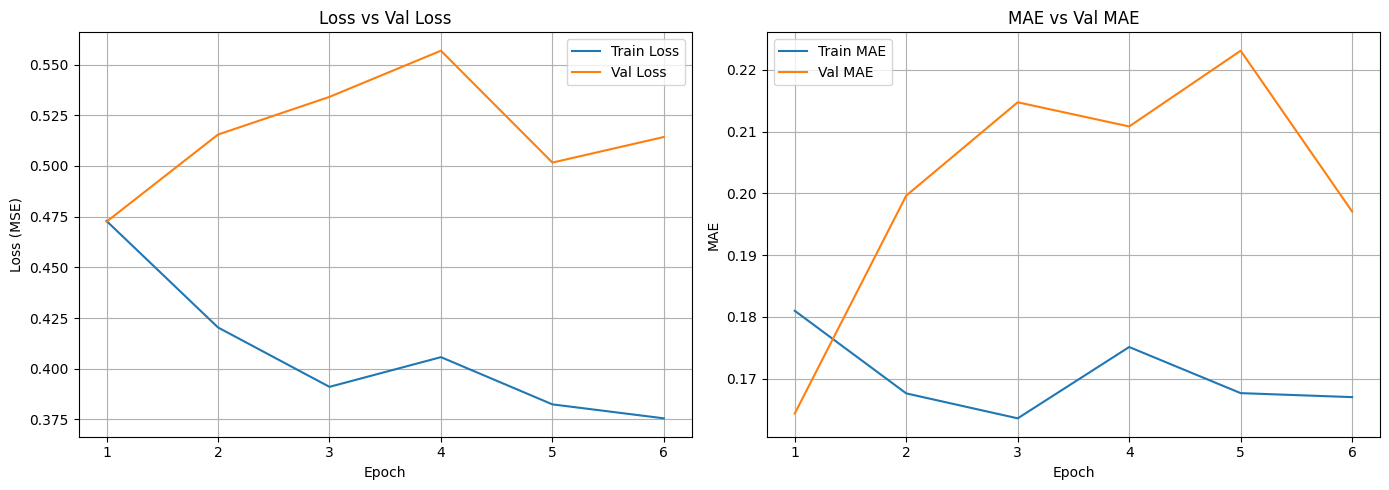

In [5]:
lstm.plot_training_history()

In [6]:
lstm.evaluate(X_test, y_test)

Test loss: 0.4585  |  MAE (scaled): 0.1643


In [8]:
lstm.save_model(name="lstm_model_2xloss")

WindowsPath('C:/Users/sacha/RiceLocal/Capstone/Coding/Flood-Forecasting/models/lstm_model_2xloss.keras')